# Training-data ablations at 120M scale (§5.5)

Two ablations off the deployed `v23.0-120M` baseline, both at the same training scale (3M steps, broad N(0,5) prior + simplify=true is the baseline):

- **A-U**: `simplify: false` — unsimplified training data. Same constants prior. Tests whether SimpliPy's benefit (shown at 20M in A-track) survives scale-up to 120M.
- **C1-uniform**: narrow $\mathcal{U}(1,5)$ constants prior. Same simplify=true. Tests the 'broader prior is better' claim from the original paper on the v23 model class, on FastSRB aggregate (not the single-Gaussian heatmap).

Produces:
- compact main-text figure (vNRR vs Test Time Compute, 3 curves).
- full-metric appendix figure (matches the A-track full-metrics layout).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

from simplipy import SimpliPyEngine

from tqdm import tqdm

from flash_ansr import get_path
from flash_ansr.eval.metrics import bootstrapped_metric_ci, naninfmean
from flash_ansr.eval import (
    arrow_notation,
    DEFAULT_NEGATIVES,
    fill_none_with_defaults,
    compute_derived_metrics,
    apply_variable_renaming,
)

In [2]:
PATH_TO_EVALUATION_DATA = get_path('results', 'evaluation', 'scaling')
os.path.exists(PATH_TO_EVALUATION_DATA)

True

In [3]:
engine = SimpliPyEngine.load('dev_7-3', install=True)

In [4]:
# 120M training-data + architecture ablations off the deployed baseline.
# All ablations share training scale (3M steps) with baseline; each one
# perturbs a single axis. Training-data ablations swap a data-pipeline
# choice (simplify or constants prior); architecture ablations revert one
# architectural component to its prior-work baseline (Biggio et al. 2021).
results = {
    'v23.0-120M':              {'scaling_parameter': 'choices'},  # baseline: broad N(0,5) prior, simplify=true
    'v23.0-120M-A-U':          {'scaling_parameter': 'choices'},  # broad prior, simplify=FALSE (unsimplified training)
    'v23.0-120M-C1-uniform':   {'scaling_parameter': 'choices'},  # NARROW U(1,5) prior, simplify=true
    'v23.0-120M-B1-postnorm':  {'scaling_parameter': 'choices'},  # post-norm decoder ablation
    'v23.0-120M-B2-16bit':     {'scaling_parameter': 'choices'},  # 16-bit input encoding ablation
    'v23.0-120M-B4-layernorm': {'scaling_parameter': 'choices'},  # LayerNorm encoder ablation
}


In [5]:
TEST_SETS = ['val', 'fastsrb'][1:]
TEST_SETS

['fastsrb']

In [6]:
models_not_found = []
for model in results.keys():
    scaling_parameter = results[model]['scaling_parameter']
    results[model]['evaluations_list'] = {}
    found_dataset = False
    for dataset in TEST_SETS:
        try:
            evaluations_list = os.listdir(os.path.join(PATH_TO_EVALUATION_DATA, model, dataset))
            found_dataset = True
        except FileNotFoundError:
            print(f"{os.path.join(PATH_TO_EVALUATION_DATA, model, dataset)} not found, skipping.")
            continue

        evaluations_list = [d for d in evaluations_list if d.startswith(f'{scaling_parameter}_')]
        scaling_values = [int(d.split('_')[-1].split('.')[0]) for d in evaluations_list]

        scaling_values_argsort = np.argsort(scaling_values)
        scaling_values = [scaling_values[i] for i in scaling_values_argsort]
        evaluations_list = [evaluations_list[i] for i in scaling_values_argsort]

        results[model]['scaling_values'] = scaling_values
        results[model]['evaluations_list'][dataset] = evaluations_list
        results[model]['results'] = {}

        print(f"{model}: Found {len(evaluations_list)} evaluations with scaling values: {scaling_values}")

    if not found_dataset:
        print(f"No datasets found for model {model}, removing from results.")
        models_not_found.append(model)

for model_not_found in models_not_found:
    del results[model_not_found]

v23.0-120M: Found 17 evaluations with scaling values: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 65536, 262144]
v23.0-120M-A-U: Found 17 evaluations with scaling values: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 65536, 262144]
v23.0-120M-C1-uniform: Found 17 evaluations with scaling values: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 65536, 262144]
/home/psaegert/Projects/flash-ansr/results/evaluation/scaling/v23.0-120M-B1-postnorm/fastsrb not found, skipping.
No datasets found for model v23.0-120M-B1-postnorm, removing from results.
/home/psaegert/Projects/flash-ansr/results/evaluation/scaling/v23.0-120M-B2-16bit/fastsrb not found, skipping.
No datasets found for model v23.0-120M-B2-16bit, removing from results.
/home/psaegert/Projects/flash-ansr/results/evaluation/scaling/v23.0-120M-B4-layernorm/fastsrb not found, skipping.
No datasets found for model v23.0-120M-B4-layernorm, removing from results.


In [7]:
# Load the evaluation results
for model in results.keys():
    scaling_parameter = results[model]['scaling_parameter']
    for dataset in TEST_SETS:
        if dataset not in results[model]['evaluations_list']:
            continue
        for d in tqdm(results[model]['evaluations_list'][dataset], desc=f'Loading {model}'):
            for test_set in TEST_SETS:
                path_to_pickle = os.path.join(PATH_TO_EVALUATION_DATA, model, test_set, d)
                if not os.path.exists(path_to_pickle):
                    continue
                with open(path_to_pickle, 'rb') as f:
                    try:
                        result = pickle.load(f)
                    except Exception as e:
                        print(f"Error loading {path_to_pickle}: {e}")
                        continue
                scaling_parameter_value = int(d.split('_')[-1].split('.')[0])
                if test_set not in results[model]['results']:
                    results[model]['results'][test_set] = {}
                results[model]['results'][test_set][scaling_parameter_value] = result

    print(f"{model} {list(results[model]['results'].keys())}")

Loading v23.0-120M: 100%|██████████| 17/17 [00:01<00:00, 10.49it/s]


v23.0-120M ['fastsrb']


Loading v23.0-120M-A-U: 100%|██████████| 17/17 [00:01<00:00, 15.99it/s]


v23.0-120M-A-U ['fastsrb']


Loading v23.0-120M-C1-uniform: 100%|██████████| 17/17 [00:01<00:00, 14.62it/s]

v23.0-120M-C1-uniform ['fastsrb']


In [8]:
# Sort scaling values
for model in results.keys():
    for test_set in TEST_SETS:
        if test_set in results[model]['results']:
            sorted_keys = sorted(results[model]['results'][test_set].keys())
            results[model]['results'][test_set] = {k: results[model]['results'][test_set][k] for k in sorted_keys}

In [9]:
fill_none_with_defaults(results, test_sets=TEST_SETS)

In [10]:
# No variable renaming needed — all models are Flash-ANSR variants
apply_variable_renaming(results, test_sets=TEST_SETS)

In [11]:
# Compute all derived metrics (FVU, NRR, symbolic recovery, edit distances, etc.)
for model in tqdm(results.keys()):
    compute_derived_metrics(
        {model: results[model]},
        test_sets=TEST_SETS,
        operator_arity=engine.operator_arity,
        simplify_fn=lambda skeleton: engine.simplify(skeleton, max_pattern_length=4),
    )

  0%|          | 0/3 [00:00<?, ?it/s]/home/psaegert/Projects/flash-ansr/src/flash_ansr/eval/metrics/numeric.py:49: RuntimeWarning: overflow encountered in square
  ss_res = np.mean((y_true - y_pred) ** 2)
 33%|███▎      | 1/3 [01:09<02:18, 69.21s/it]/home/psaegert/Projects/flash-ansr/src/flash_ansr/eval/metrics/numeric.py:54: RuntimeWarning: overflow encountered in square
  ss_res = np.mean((y_true * scale - y_pred * scale) ** 2)
/home/psaegert/miniconda3/envs/flash-ansr/lib/python3.13/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
100%|██████████| 3/3 [03:26<00:00, 68.67s/it]


In [12]:
fill_none_with_defaults(results, test_sets=TEST_SETS)

## Compact main-text figure (2-panel: vNRR + Expression Length Ratio)

Matches the style of the main-text test-time-compute scaling figure (`test_time_compute_scaling.ipynb`):
single-shape `.` markers, `set_title` as the metric label, `'0.1s'/.../1000s'` xtick text, mean/median annotation in the upper-left of each panel, per-panel legend.

Three curves: baseline (broad prior, simplified training) wins on both axes against both ablations on FastSRB.

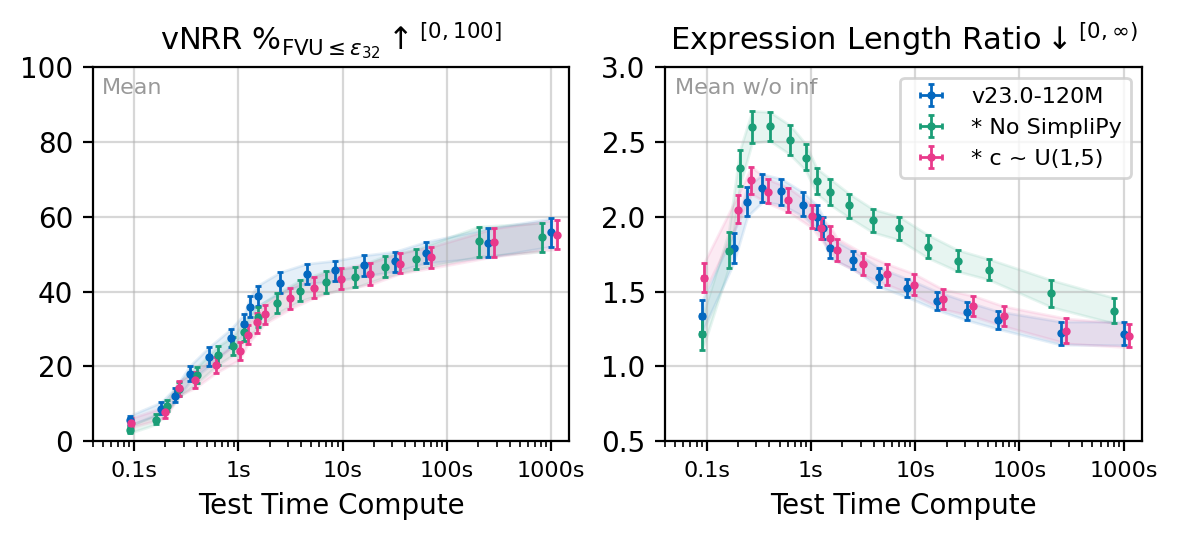

In [13]:
# 2-panel compact figure for §5.6 main text. Style matches test_time_compute_scaling.ipynb.
# Now combines training-data and architecture ablations off the deployed 120M baseline;
# kept on the same figure to avoid an additional page-budget hit (six curves total).
if len(TEST_SETS) == 1:
    test_set = TEST_SETS[0]
else:
    test_set = 'fastsrb'

metric_pairs_compact = [
    (('fit_time', 'Test Time Compute', naninfmean), (
        'numeric_recovery_val',
        f'vNRR $\\%_{{\\mathrm{{FVU}} \\leq \\epsilon_{{32}}}} {arrow_notation(objective=1, lower=0, upper=100)}$',
        np.nanmean,
        100,
        (0, 100),
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'skeleton_length_ratio',
        f'$\\mathrm{{Expression\\ Length\\ Ratio}} {arrow_notation(objective=-1, lower=0, upper=np.inf)}$',
        naninfmean,
        1,
        (0.5, 3),
    )),
]

# Color palette (all-solid, distinct hues per the camera-ready figure design):
#   Training-data group:
#     baseline blue   #0468BF -- canonical 120M color from main results figure
#     teal-green      #1B9E77 -- No SimpliPy (distinct from E2E's pure green)
#     magenta         #E93A8B -- narrow-prior c ~ U(1,5)
#   Architecture group (chosen to be visually separable from the above):
#     gold            #E6A800 -- B1 post-norm decoder
#     purple          #7A4F9C -- B2 16-bit input encoding
#     brown           #8B5A3C -- B4 LayerNorm encoder
# All curves are drawn solid with circle markers; the legend orders them by
# axis group with a blank spacer so the reader can read off the grouping.
models_compact = [
    ('v23.0-120M',              'choices', '#0468BF', 'v23.0-120M'),
    ('v23.0-120M-A-U',          'choices', '#1B9E77', '* No SimpliPy'),
    ('v23.0-120M-C1-uniform',   'choices', '#E93A8B', '* c ~ U(1,5)'),
    ('v23.0-120M-B1-postnorm',  'choices', '#E6A800', '* Post-Norm'),
    ('v23.0-120M-B2-16bit',     'choices', '#7A4F9C', '* 16-bit'),
    ('v23.0-120M-B4-layernorm', 'choices', '#8B5A3C', '* LayerNorm'),
]
models_compact = [m for m in models_compact if m[0] in results.keys()]

COLS = len(metric_pairs_compact)
ROWS = 1

fig, axes = plt.subplots(ROWS, COLS, figsize=(3 * COLS, 2.8 * ROWS), dpi=200)

for ax_id, (ax, ((x_metric, x_label, x_statistic), (y_metric, y_label, y_statistic, y_factor, ylim))) in enumerate(zip(axes.flatten(), metric_pairs_compact)):
    for model_name, scaling_param, color, model_label in models_compact:
        if model_name not in results or test_set not in results[model_name]['results']:
            continue

        x_median, x_lower, x_upper = [], [], []
        y_median, y_lower, y_upper = [], [], []

        for n in results[model_name]['results'][test_set].keys():
            if len(results[model_name]['results'][test_set][n][x_metric]) not in [1200, 600, 120, 1000, 500, 100]:
                continue

            x = results[model_name]['results'][test_set][n][x_metric]
            y = results[model_name]['results'][test_set][n][y_metric]

            if y_metric == 'only_approx_log10_fvu_val':
                y = y[y != -np.inf]

            x_ci = bootstrapped_metric_ci(x, x_statistic, n=1e3, interval=0.95)
            y_ci = bootstrapped_metric_ci(y, y_statistic, n=1e3, interval=0.95)

            x_median.append(x_ci[0]); x_lower.append(x_ci[1]); x_upper.append(x_ci[2])
            y_median.append(y_ci[0]); y_lower.append(y_ci[1]); y_upper.append(y_ci[2])

        if ylim[0] is not None and ylim[1] is not None:
            ax.set_ylim(ylim)

        x_median, x_lower, x_upper = np.array(x_median), np.array(x_lower), np.array(x_upper)
        y_median, y_lower, y_upper = np.array(y_median) * y_factor, np.array(y_lower) * y_factor, np.array(y_upper) * y_factor

        # 1. Standard plotting
        ax.errorbar(
            x_median, y_median,
            yerr=[y_median - y_lower, y_upper - y_median],
            xerr=[x_median - x_lower, x_upper - x_median],
            fmt='.', label=model_label, capsize=1, color=color, elinewidth=1, markersize=4,
        )
        ax.fill_between(x_median, y_lower, y_upper, color=color, alpha=0.1)

        # 2. Out-of-bounds indicators (upper limit)
        if ylim[1] is not None:
            upper_limit = ylim[1]
            oob_mask = y_median > upper_limit
            if np.any(oob_mask):
                ax.plot(
                    x_median[oob_mask],
                    np.full(oob_mask.sum(), upper_limit),
                    marker='o', linestyle='None',
                    markerfacecolor='white', markeredgecolor=color,
                    markeredgewidth=1.0, markersize=3,
                    clip_on=False, zorder=100,
                )
                print(f"Model {model_name} has {oob_mask.sum()} out-of-bounds points for metric {y_metric} (upper limit: {upper_limit})")

    # Annotate if mean or median is used
    y_statistic_name = {
        np.nanmean: 'Mean',
        np.nanmedian: 'Median',
        naninfmean: 'Mean w/o inf',
    }
    ax.annotate(y_statistic_name[y_statistic], xy=(0.02, 0.97), xycoords='axes fraction',
                fontsize=8, color='k', ha='left', va='top', alpha=0.4)

    ax.set_title(y_label, fontsize=11)
    ax.set_xscale('log')
    ax.set_xlim(0.04, 1500)
    ax.set_xticks([0.1, 1, 10, 100, 1000])
    ax.set_xticklabels(['0.1s', '1s', '10s', '100s', '1000s'], fontsize=8)
    ax.grid(alpha=0.5)

    if ax_id // COLS == ROWS - 1:
        ax.set_xlabel(x_label)

# Legend on the right panel (Expression Length Ratio), upper-right.
axes.flatten()[-1].legend(fontsize=8, loc='upper right')

fig.tight_layout(w_pad=0.5, h_pad=2)
fig.savefig(get_path('results', 'figures', 'training_data_ablations_120M', create=True, filename=f'training_data_ablations_120M_compact_{test_set}.svg'), dpi=200)
fig.savefig(get_path('results', 'figures', 'training_data_ablations_120M', create=True, filename=f'training_data_ablations_120M_compact_{test_set}.pdf'), dpi=200)
plt.show()


## Full multi-metric appendix figure

Mirrors the A-track full-metrics layout (`a_track_full_metrics_*.svg`). Used in the appendix for completeness; the main text only references the compact panel above.

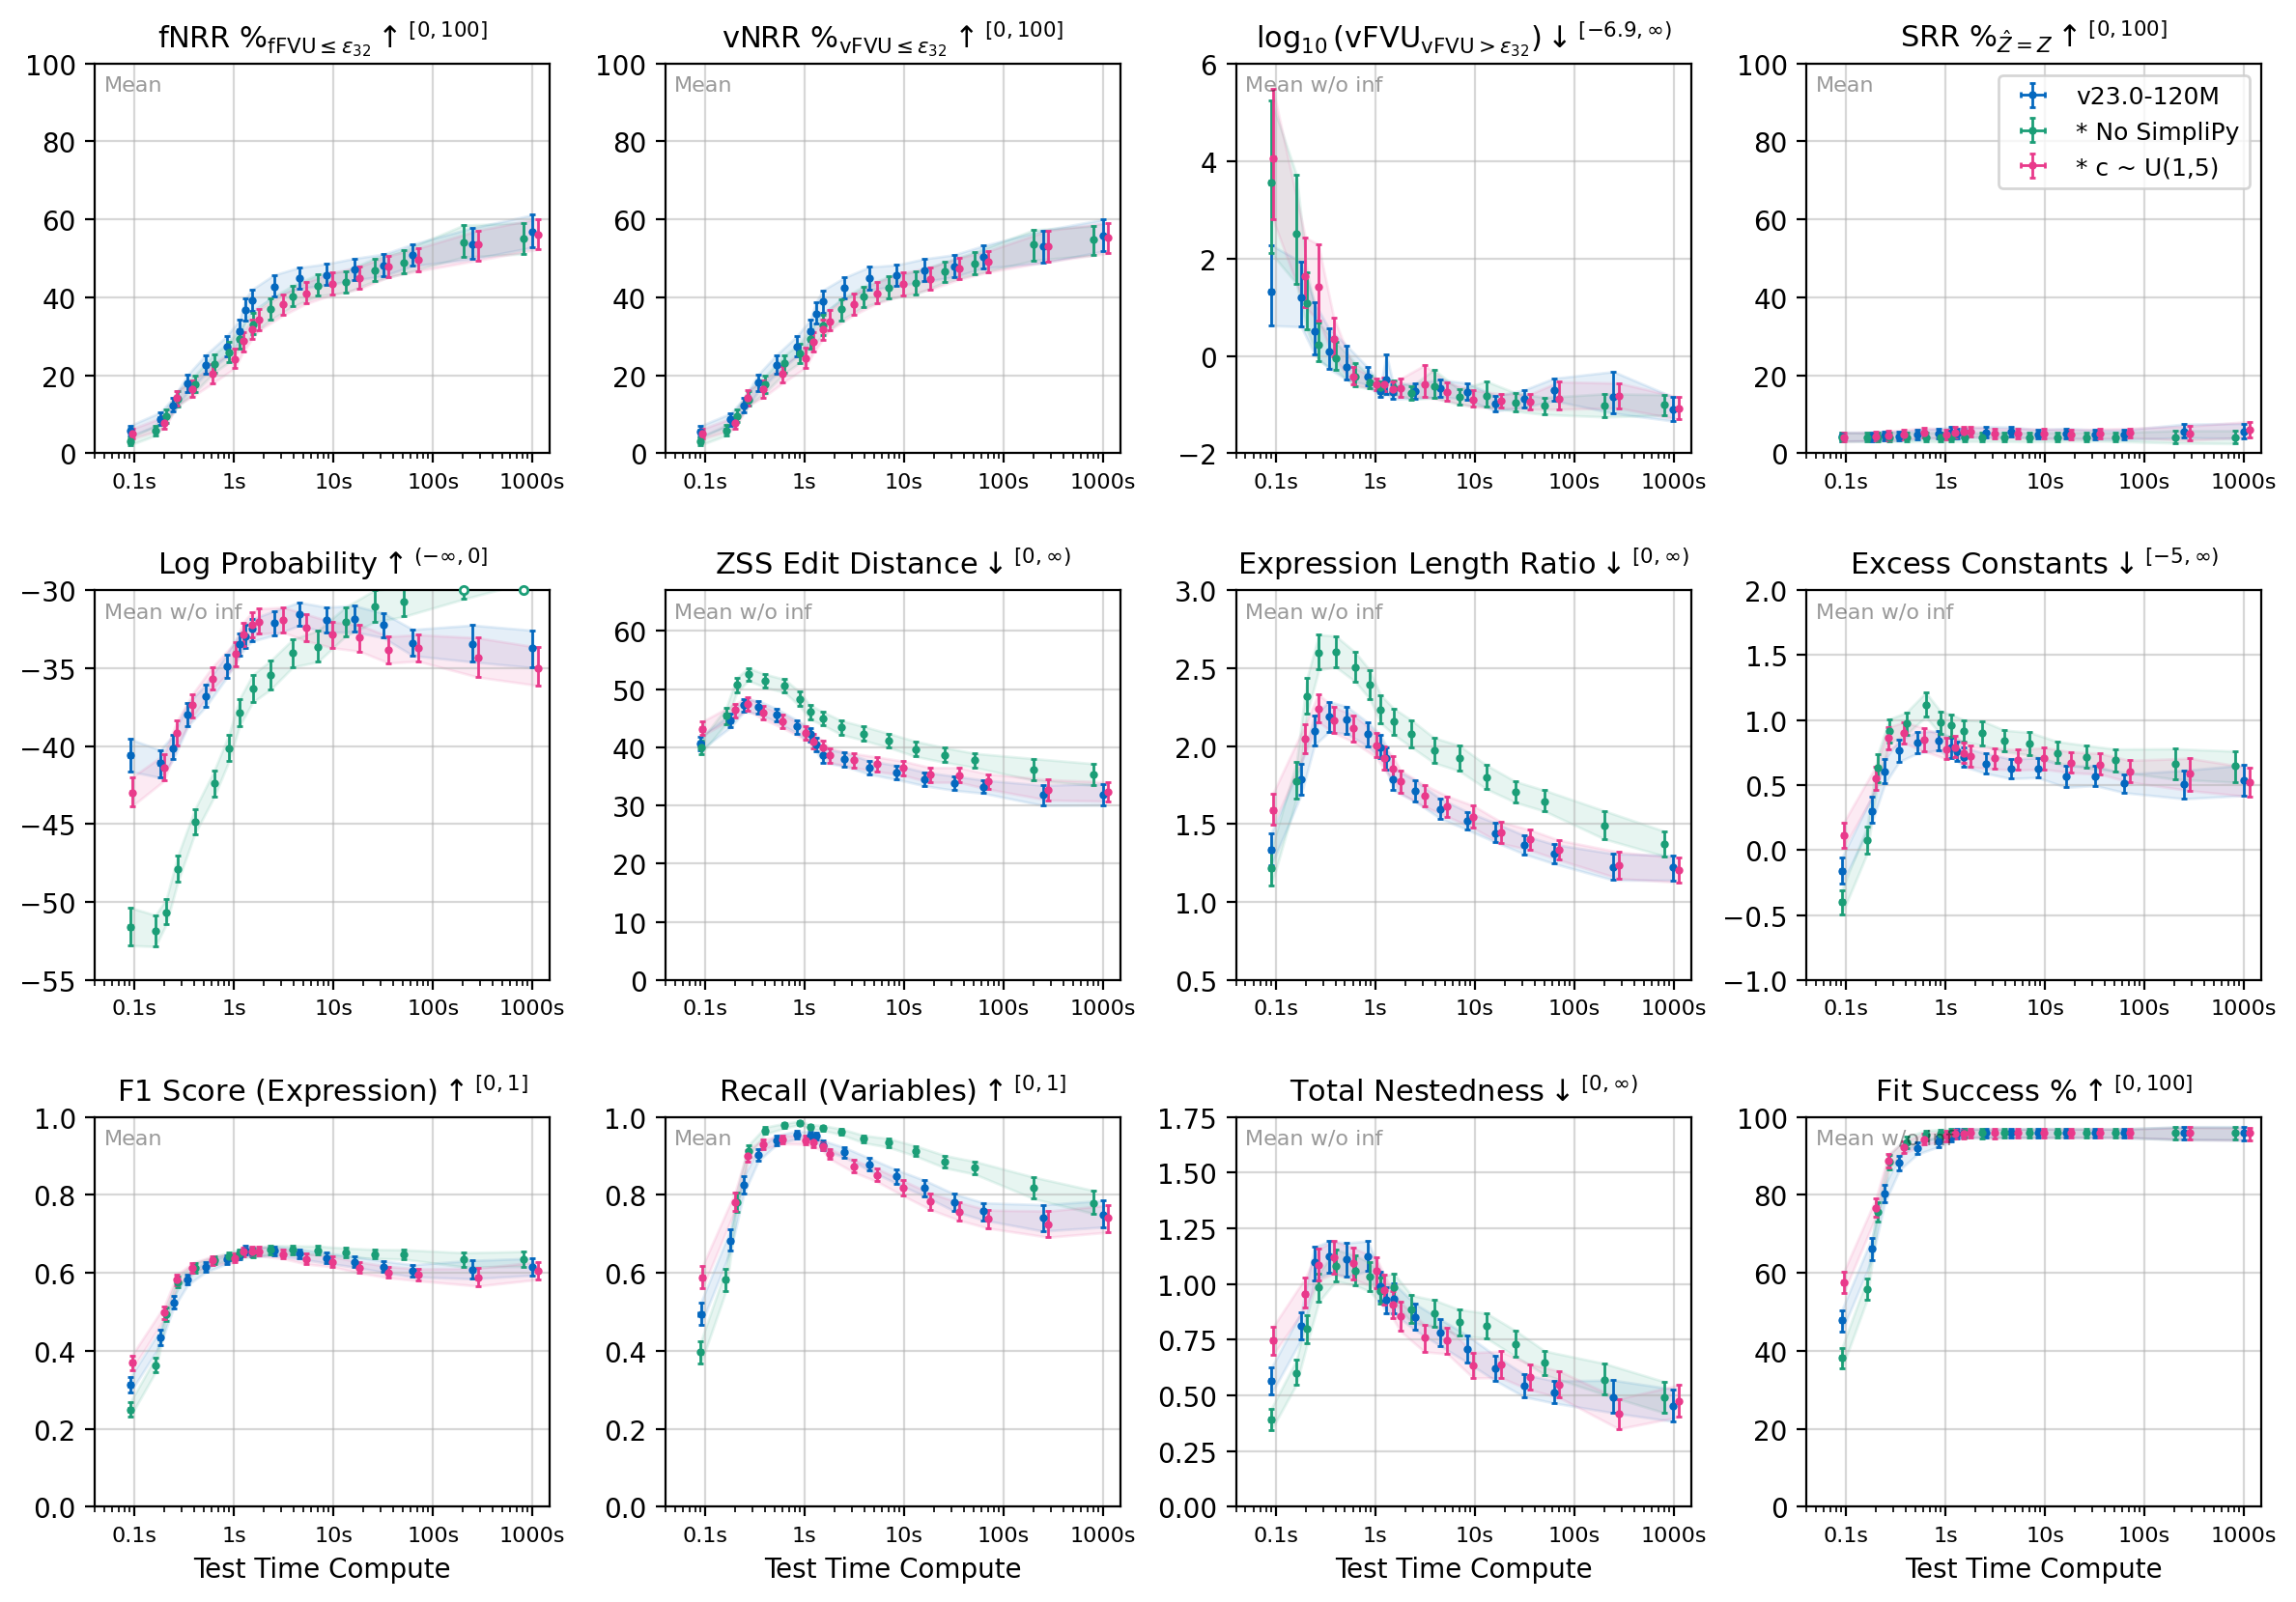

In [14]:
# Determine max_gt_constants from the first available model/scaling level
first_model = list(results.keys())[0]
first_test_set = TEST_SETS[0]
first_scaling_value = sorted(results[first_model]['results'][first_test_set].keys())[0]
gt_constants = results[first_model]['results'][first_test_set][first_scaling_value]['n_constants']
max_gt_constants = max(gt_constants[np.isfinite(gt_constants)])

metric_pairs = [
    (('fit_time', 'Test Time Compute', naninfmean), (
        'numeric_recovery_fit',
        f'fNRR $\\%_{{\\mathrm{{fFVU}} \\leq \\epsilon_{{32}}}} {arrow_notation(objective=1, lower=0, upper=100)}$',
        np.nanmean, 100, (0, 100),
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'numeric_recovery_val',
        f'vNRR $\\%_{{\\mathrm{{vFVU}} \\leq \\epsilon_{{32}}}} {arrow_notation(objective=1, lower=0, upper=100)}$',
        np.nanmean, 100, (0, 100),
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'only_approx_log10_fvu_val',
        f'$\\log_{{10}}(\\mathrm{{vFVU}}_{{\\mathrm{{vFVU}} > \\epsilon_{{32}}}}) {arrow_notation(objective=-1, lower=np.log10(np.finfo(np.float32).eps), upper=np.inf)}$',
        naninfmean, 1, (-2, 6),
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'symbolic_recovery',
        f'SRR $\\%_{{\\hat{{Z}} = Z}} {arrow_notation(objective=1, lower=0, upper=100)}$',
        np.nanmean, 100, (0, 100),
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'predicted_log_prob',
        f'$\\mathrm{{Log\\ Probability}} {arrow_notation(objective=1, lower=-np.inf, upper=0)}$',
        naninfmean, 1, (-55, -30),
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'zss_edit_distance',
        f'$\\mathrm{{ZSS\\ Edit\\ Distance}} {arrow_notation(objective=-1, lower=0, upper=np.inf)}$',
        naninfmean, 1, (0, 67),
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'skeleton_length_ratio',
        f'$\\mathrm{{Expression\\ Length\\ Ratio}} {arrow_notation(objective=-1, lower=0, upper=np.inf)}$',
        naninfmean, 1, (0.5, 3),
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'n_constants_delta',
        f'$\\mathrm{{Excess\\ Constants}} {arrow_notation(objective=-1, lower=-max_gt_constants, upper=np.inf)}$',
        naninfmean, 1, (-1, 2),
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'f1_score',
        f'$\\mathrm{{F1\\ Score\\ (Expression)}} {arrow_notation(objective=1, lower=0, upper=1)}$',
        np.nanmean, 1, (0.0, 1),
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'recall_unique_variables',
        f'$\\mathrm{{Recall\\ (Variables)}} {arrow_notation(objective=1, lower=0, upper=1)}$',
        np.nanmean, 1, (0, 1),
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'predicted_total_nestedness',
        f'$\\mathrm{{Total\\ Nestedness}} {arrow_notation(objective=-1, lower=0, upper=np.inf)}$',
        naninfmean, 1, (0, 1.75),
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'prediction_success',
        f'$\\mathrm{{Fit\\ Success}}\\ \\% {arrow_notation(objective=1, lower=0, upper=100)}$',
        naninfmean, 100, (0, 100),
    )),
]

# Same color/label assignment as the compact figure for consistency.
models = [
    ('v23.0-120M',            'choices', '#0468BF', 'v23.0-120M'),
    ('v23.0-120M-A-U', 'choices', '#1B9E77', '* No SimpliPy'),
    ('v23.0-120M-C1-uniform', 'choices', '#E93A8B', '* c ~ U(1,5)'),
]
models = [m for m in models if m[0] in results.keys()]

# Index of the SRR panel within metric_pairs (used to place the legend).
SRR_AX_INDEX = next(i for i, ((_, _, _), (m, *_)) in enumerate(metric_pairs) if m == 'symbolic_recovery')

COLS = min(4, len(metric_pairs))
ROWS = int(np.ceil(len(metric_pairs) / COLS))

fig, axes = plt.subplots(ROWS, COLS, figsize=(3 * COLS, 2.8 * ROWS), dpi=200)

for ax_id, (ax, ((x_metric, x_label, x_statistic), (y_metric, y_label, y_statistic, y_factor, ylim))) in enumerate(zip(axes.flatten(), metric_pairs)):
    for model_name, scaling_param, color, model_label in models:
        if model_name not in results or test_set not in results[model_name]['results']:
            continue

        x_median, x_lower, x_upper = [], [], []
        y_median, y_lower, y_upper = [], [], []

        for n in results[model_name]['results'][test_set].keys():
            if len(results[model_name]['results'][test_set][n][x_metric]) not in [1200, 600, 120, 1000, 500, 100]:
                continue

            x = results[model_name]['results'][test_set][n][x_metric]
            y = results[model_name]['results'][test_set][n][y_metric]

            if y_metric == 'only_approx_log10_fvu_val':
                y = y[y != -np.inf]

            x_ci = bootstrapped_metric_ci(x, x_statistic, n=1e3, interval=0.95)
            y_ci = bootstrapped_metric_ci(y, y_statistic, n=1e3, interval=0.95)

            x_median.append(x_ci[0]); x_lower.append(x_ci[1]); x_upper.append(x_ci[2])
            y_median.append(y_ci[0]); y_lower.append(y_ci[1]); y_upper.append(y_ci[2])

        if ylim[0] is not None and ylim[1] is not None:
            ax.set_ylim(ylim)

        x_median, x_lower, x_upper = np.array(x_median), np.array(x_lower), np.array(x_upper)
        y_median, y_lower, y_upper = np.array(y_median) * y_factor, np.array(y_lower) * y_factor, np.array(y_upper) * y_factor

        # 1. Standard plotting
        ax.errorbar(
            x_median, y_median,
            yerr=[y_median - y_lower, y_upper - y_median],
            xerr=[x_median - x_lower, x_upper - x_median],
            fmt='.', label=model_label, capsize=1, color=color, elinewidth=1, markersize=4,
        )
        ax.fill_between(x_median, y_lower, y_upper, color=color, alpha=0.1)

        # 2. Out-of-bounds indicators (upper limit)
        if ylim[1] is not None:
            upper_limit = ylim[1]
            oob_mask = y_median > upper_limit
            if np.any(oob_mask):
                ax.plot(
                    x_median[oob_mask],
                    np.full(oob_mask.sum(), upper_limit),
                    marker='o', linestyle='None',
                    markerfacecolor='white', markeredgecolor=color,
                    markeredgewidth=1.0, markersize=3,
                    clip_on=False, zorder=100,
                )

    y_statistic_name = {np.nanmean: 'Mean', np.nanmedian: 'Median', naninfmean: 'Mean w/o inf'}
    ax.annotate(y_statistic_name[y_statistic], xy=(0.02, 0.97), xycoords='axes fraction',
                fontsize=8, color='k', ha='left', va='top', alpha=0.4)

    ax.set_title(y_label, fontsize=11)
    ax.set_xscale('log')
    ax.set_xlim(0.04, 1500)
    ax.set_xticks([0.1, 1, 10, 100, 1000])
    ax.set_xticklabels(['0.1s', '1s', '10s', '100s', '1000s'], fontsize=8)
    ax.grid(alpha=0.5)

    if ax_id // COLS == ROWS - 1:
        ax.set_xlabel(x_label)

# Legend on the SRR panel, upper-right.
axes.flatten()[SRR_AX_INDEX].legend(fontsize=9, loc='upper right')

for ax_id, ax in enumerate(axes.flatten()[len(metric_pairs):]):
    ax.axis('off')
    if (ax_id + len(metric_pairs)) // COLS == ROWS - 1:
        axes.flatten()[len(metric_pairs) - COLS + (ax_id % COLS)].set_xlabel(x_label)

fig.tight_layout(w_pad=0.5, h_pad=2)
fig.savefig(get_path('results', 'figures', 'training_data_ablations_120M', create=True, filename=f'training_data_ablations_120M_full_metrics_{test_set}.svg'), dpi=200)
plt.show()

## Numerical summary table

Prints vNRR / median FVU at headline compute budgets. Useful for the paper text and as a sanity check that the figures are showing the right numbers.

In [15]:
EPS = float(np.finfo(np.float32).eps)
headline_choices = [64, 256, 1024, 4096, 16384]

rows = []
for c in headline_choices:
    row = {'choices': c}
    for m in [n[0] for n in models]:
        if m not in results or test_set not in results[m]['results']:
            continue
        if c not in results[m]['results'][test_set]:
            continue
        d = results[m]['results'][test_set][c]
        nrr = float(np.nanmean(d['numeric_recovery_val'])) * 100
        # median of finite-only FVU on val set
        fvu = d.get('fvu_val')
        if fvu is not None:
            finite = fvu[np.isfinite(fvu)]
            med_fvu = float(np.median(finite)) if finite.size else float('nan')
        else:
            med_fvu = float('nan')
        row[m + '_vNRR'] = nrr
        row[m + '_medFVU'] = med_fvu
    rows.append(row)

import pandas as pd
df = pd.DataFrame(rows)
df

,choices,v23.0-120M_vNRR,v23.0-120M_medFVU,v23.0-120M-A-U_vNRR,v23.0-120M-A-U_medFVU,v23.0-120M-C1-uniform_vNRR,v23.0-120M-C1-uniform_medFVU
0,64,31.416667,6.857712e-02,25.583333,3.325769e-01,28.500000,1.736857e-01
1,256,38.833333,2.125367e-03,33.000000,5.080143e-02,33.916667,2.961385e-02
2,1024,44.833333,1.810776e-04,40.166667,3.984259e-04,41.083333,3.138131e-04
3,4096,47.000000,9.696073e-07,43.750000,3.255867e-05,44.833333,2.983044e-05
4,16384,50.500000,5.269251e-10,48.666667,2.853536e-08,49.166667,2.139768e-08
